In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:\Dataset\Loan Prediction Dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
df.shape

(614, 13)

In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
missing_catg = ['Gender','Married','Self_Employed','Dependents']

In [7]:
for i in missing_catg:
    df[i] = df[i].fillna(df[i].mode()[0])

In [8]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
missing_num = ['LoanAmount','Loan_Amount_Term','Credit_History']
for i in missing_num:
    df[i] = df[i].fillna(df[i].mode()[0])

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.465798,342.410423,0.855049
std,6109.041673,2926.248369,84.180967,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


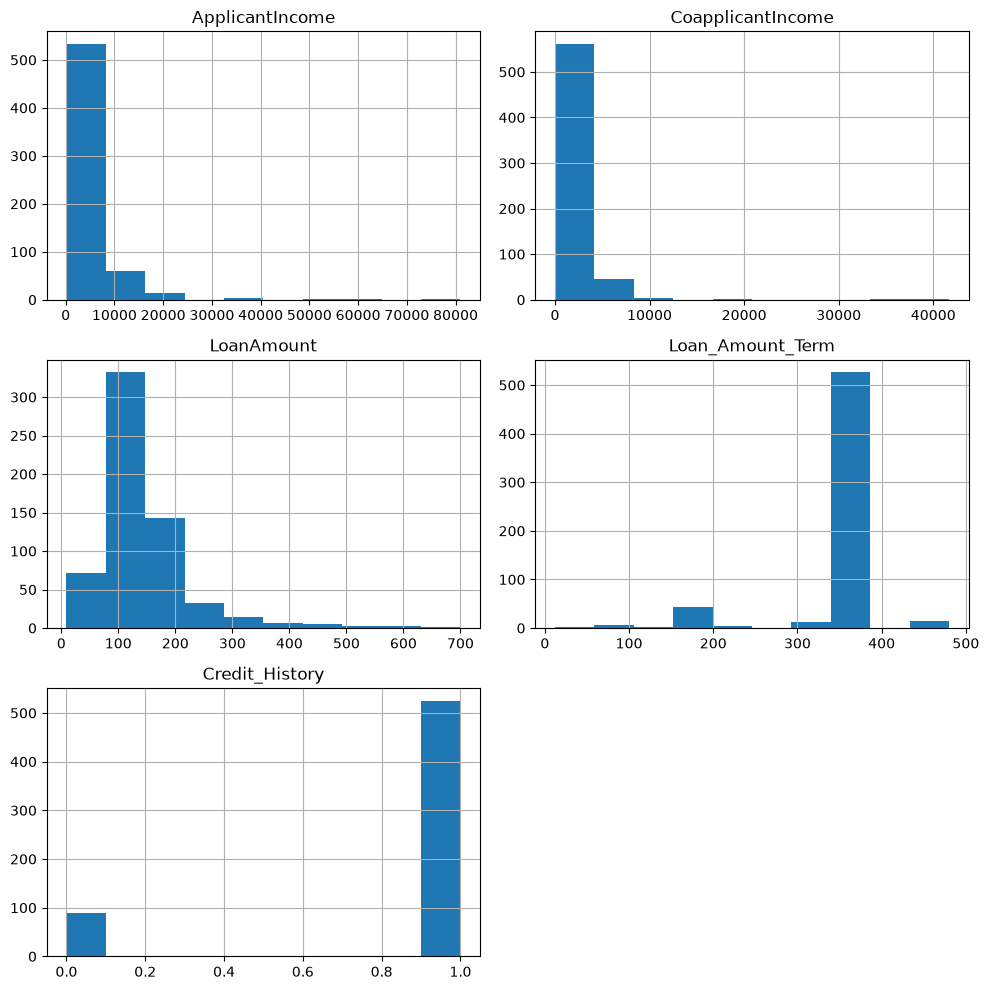

In [12]:
df.hist(figsize=(10,10))
plt.tight_layout()

In [13]:
df.select_dtypes('object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


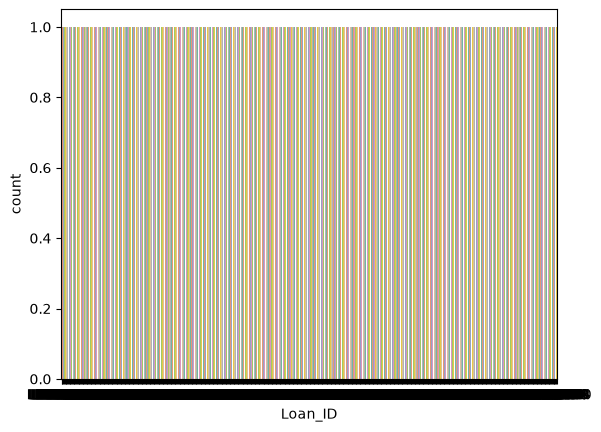

<Figure size 1000x1000 with 0 Axes>

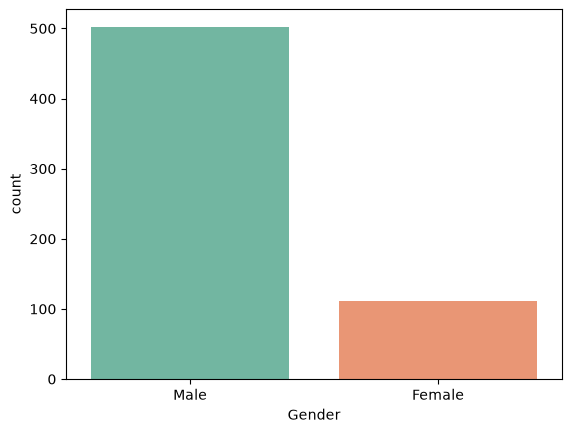

<Figure size 1000x1000 with 0 Axes>

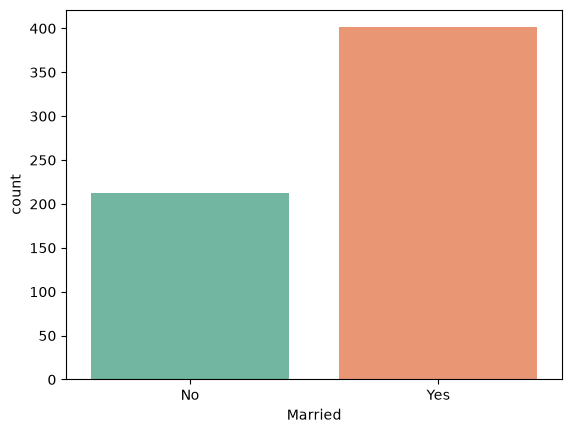

<Figure size 1000x1000 with 0 Axes>

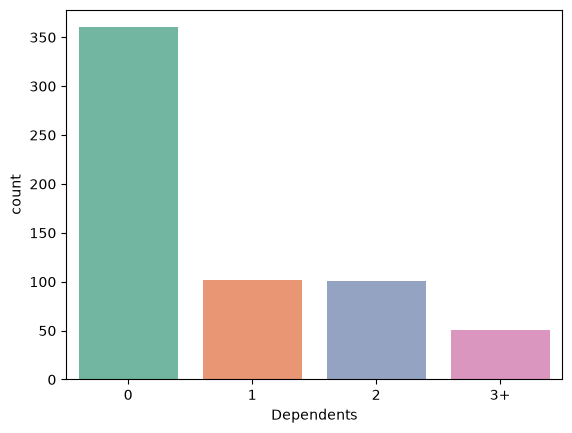

<Figure size 1000x1000 with 0 Axes>

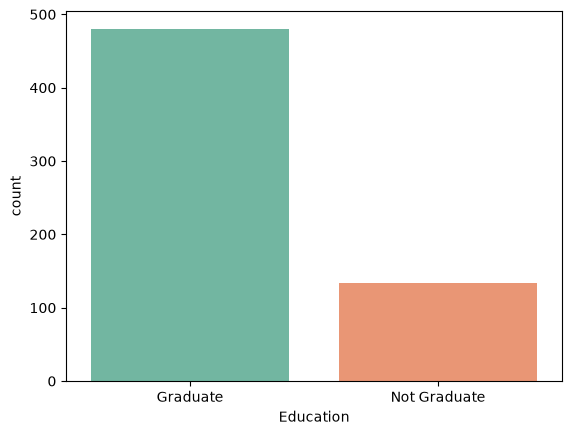

<Figure size 1000x1000 with 0 Axes>

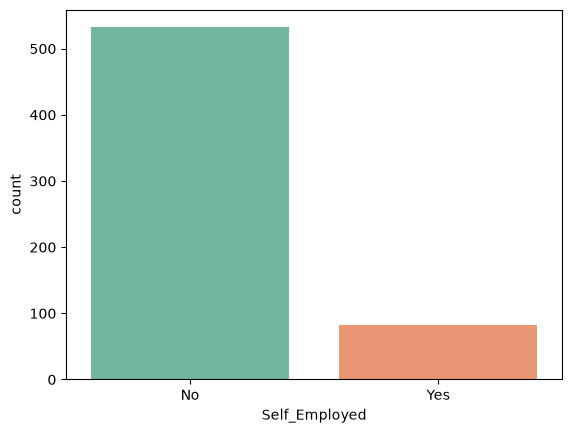

<Figure size 1000x1000 with 0 Axes>

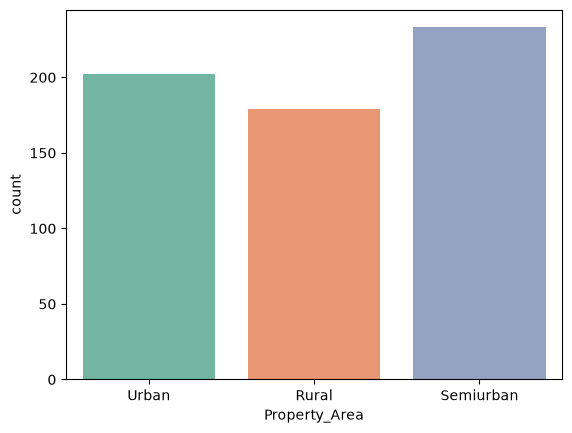

<Figure size 1000x1000 with 0 Axes>

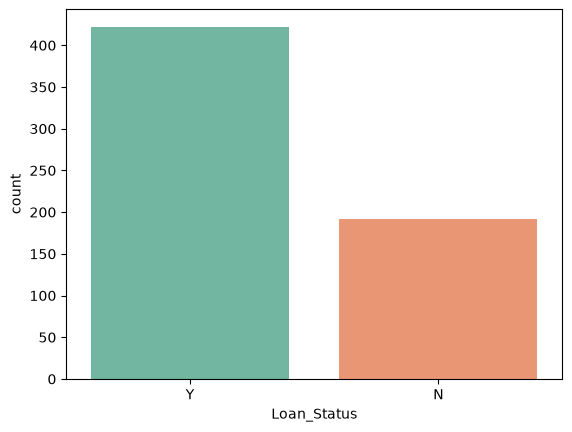

<Figure size 1000x1000 with 0 Axes>

In [14]:
for i in df.select_dtypes('object').columns:
    sns.countplot(x= i, data = df,palette ='Set2')
    plt.figure(figsize=(10,10))
    plt.show()

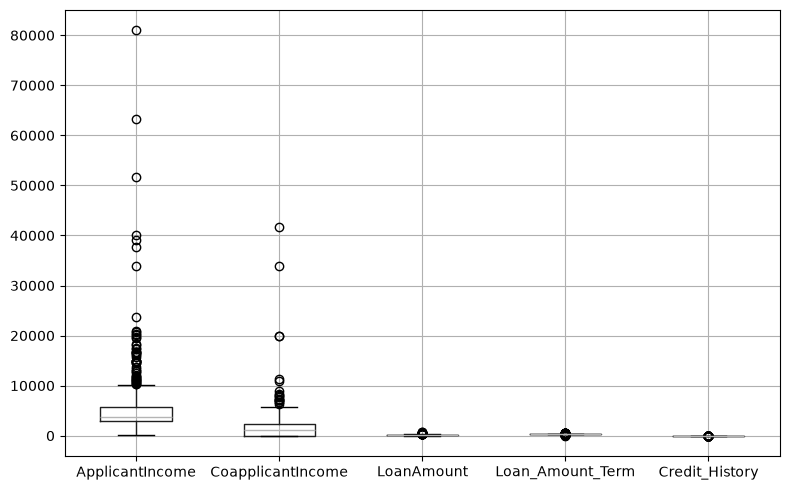

In [15]:
df.boxplot(figsize=(8,5))
plt.tight_layout()

In [16]:
for i in df.select_dtypes('object').columns:
    df[i] = df[i].astype('category')

In [17]:
df.dtypes

Loan_ID              category
Gender               category
Married              category
Dependents           category
Education            category
Self_Employed        category
ApplicantIncome         int64
CoapplicantIncome     float64
LoanAmount            float64
Loan_Amount_Term      float64
Credit_History        float64
Property_Area        category
Loan_Status          category
dtype: object

In [18]:
df = df.drop(columns = ['Loan_ID'])

In [19]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [20]:
corr = df.select_dtypes(include='number').corr()
corr

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.564698,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189723,-0.059383,0.011134
LoanAmount,0.564698,0.189723,1.000000,0.037152,-0.000250
Loan_Amount_Term,-0.046531,-0.059383,0.037152,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000250,-0.004705,1.000000


<Axes: >

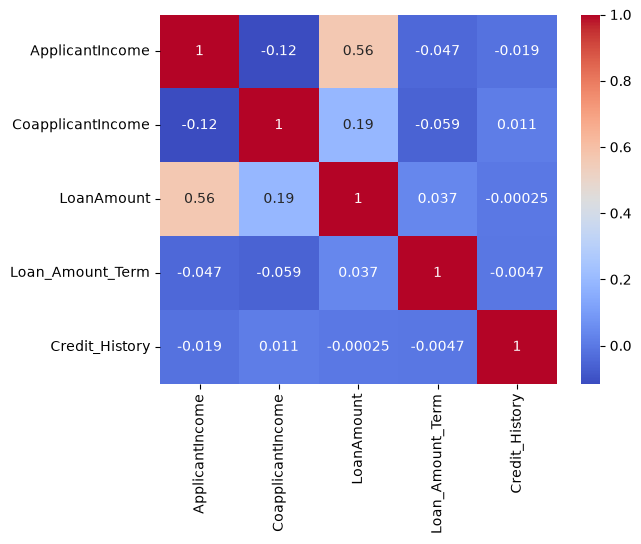

In [21]:
sns.heatmap(corr,cmap='coolwarm',annot=True)

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.select_dtypes('category').columns:
    df[i] = le.fit_transform(df[i])

In [23]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [24]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [25]:
x = df.drop(columns='Loan_Status')
y = df['Loan_Status']

In [26]:
from sklearn.model_selection import train_test_split ###made mistake on model.selection and T caps
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression ###missed underscore between linearmodel
model = LogisticRegression()
model.fit(x_train,y_train) # made mistake of using standard scaler instead of fit

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [28]:
y_pred = model.predict(x_test)

In [29]:
score = model.score(x_test,y_test)*100
score

78.37837837837837

In [30]:
from sklearn.model_selection import cross_val_score ## should be model selection than metrics
cv = cross_val_score(model,x,y,cv=5)

In [31]:
cv_score = (cv.mean())*100
cv_score 

np.float64(80.61975209916034)

In [32]:
from sklearn.metrics import confusion_matrix### made mistake of C on caps
cm = confusion_matrix(y_test,y_pred)
cm

array([[ 27,  38],
       [  2, 118]])

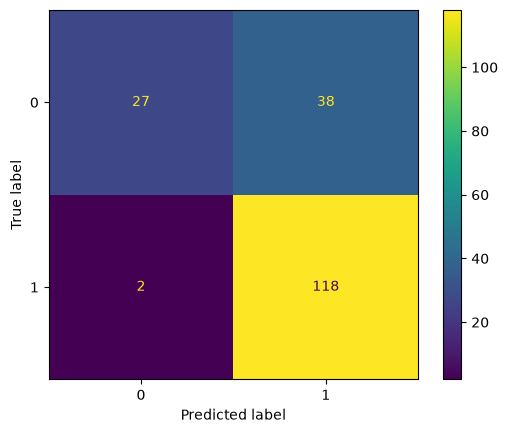

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm)
cm_display.plot() ###missed plot

In [34]:
from sklearn.metrics import classification_report
Base_model_report = classification_report(y_test,y_pred)

### Scaled Model

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_test_scaled = sc.fit_transform(x_test)
x_train_scaled = sc.transform(x_train)

In [36]:
from sklearn.linear_model import LogisticRegression
model_scaled = LogisticRegression()
model_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
y_pred_sc = model_scaled.predict(x_test_scaled)

In [38]:
from sklearn.model_selection import cross_val_score ## should be model selection than metrics
cv_score = cross_val_score(model,x,y,cv=5)
cv_scaled_score = cross_val_score(model_scaled,x,y,cv=5)

In [39]:
scaled_model_score = model_scaled.score(x_test_scaled,y_test)*100
print('Model_score:',score)
print('Cross_validation_score:',cv_score.mean()*100)
print('Scaled_Model_score:',scaled_model_score)
print('Cross_validation_Scaled_score:',cv_scaled_score.mean()*100)

Model_score: 78.37837837837837
Cross_validation_score: 80.61975209916034
Scaled_Model_score: 78.37837837837837
Cross_validation_Scaled_score: 80.61975209916034


In [40]:
from sklearn.metrics import classification_report
Base_scaled_model_report = classification_report(y_test,y_pred_sc)

In [41]:
print(Base_scaled_model_report ) # see imbalanced in support so that recall is slow due to moderate imbalance, 70:30 normal , use balanced parameter in Logistic rgeression fucntion

              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185



In [42]:
y_train.value_counts(normalize=True)

Loan_Status
1    0.703963
0    0.296037
Name: proportion, dtype: float64

#### Balanced Model to Improve the Result

In [43]:
balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_model.fit(x_train, y_train)

y_pred_bal = balanced_model.predict(x_test)

In [44]:
balanced_model_score = balanced_model.score(x_test,y_test)*100 #Investigated why we get 35%-- y_pred_rename
balanced_model_score

71.89189189189189

In [45]:
cm_bal = confusion_matrix(y_test,y_pred_bal)
cm_bal

array([[34, 31],
       [21, 99]])

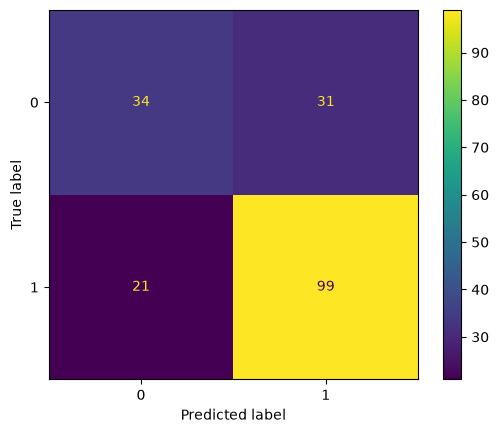

In [46]:
cm_bal_display = ConfusionMatrixDisplay(cm_bal)
cm_bal_display.plot()


In [47]:
Balanced_model_report = classification_report(y_test, y_pred_bal)

In [48]:
cv_b = cross_val_score(balanced_model,x,y,cv=5)
cv_balanced_model_score = cv_b.mean()*100

#### Balanced Model with Scaled data

In [49]:
balanced_scaled_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

balanced_scaled_model.fit(x_train_scaled, y_train)

y_pred_bal_scaled = balanced_scaled_model.predict(x_test_scaled)


Balanced_scaled_report = classification_report(y_test, y_pred_bal_scaled)

In [50]:
balanced_scaled_model_score = balanced_scaled_model.score(x_test_scaled,y_test)*100
balanced_scaled_model_score

74.5945945945946

In [51]:
cm_bal_scaled = confusion_matrix(y_test,y_pred_bal_scaled)
cm_bal_scaled

array([[ 29,  36],
       [ 11, 109]])

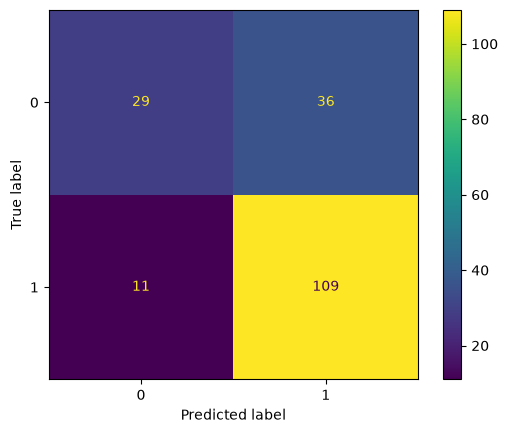

In [52]:
cm_bal_sc_display = ConfusionMatrixDisplay(cm_bal_scaled)
cm_bal_sc_display.plot()

In [53]:
cv_b_sc = cross_val_score(balanced_scaled_model,x,y,cv=5)
cv_balanced_scaled_model_score = cv_b_sc.mean()*100

In [54]:
print('Model_score:',score)
print('Cross_validation_score:',(cv_score.mean()*100))
print('Scaled_Model_score:',scaled_model_score)
print('Cross_validation_Scaled_score:',cv_scaled_score.mean()*100)
print("Balanced_Model Score",balanced_model_score)
print("Balanced_Model_Cv_score",cv_balanced_model_score)
print("Balanced_Scaled_Model Score",balanced_scaled_model_score)
print("Balanced_Scaled_Model_Cv_score",cv_balanced_scaled_model_score)


Model_score: 78.37837837837837
Cross_validation_score: 80.61975209916034
Scaled_Model_score: 78.37837837837837
Cross_validation_Scaled_score: 80.61975209916034
Balanced_Model Score 71.89189189189189
Balanced_Model_Cv_score 76.05491136878581
Balanced_Scaled_Model Score 74.5945945945946
Balanced_Scaled_Model_Cv_score 76.05491136878581


#### Hyperparameter Tuning

In [86]:
from sklearn.model_selection import GridSearchCV
param_grid = { 'solver':['lbfgs', 'liblinear', 'newton-cg','saga'],
'penalty' : ['l1', 'l2', 'elasticnet'] }
grid = GridSearchCV( LogisticRegression(random_state = 42) , param_grid , refit = True , verbose = 3, n_jobs = -1,scoring = 'f1_weighted')
grid.fit(x_train_scaled,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. 

In [87]:
grid_result = grid.cv_results_
grid_result_table = pd.DataFrame(grid_result)
grid_result_table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001798,0.000746,0.000000,0.000000,l1,lbfgs,"{'penalty': 'l1', 'solver': 'lbfgs'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
1,0.025324,0.017988,0.013960,0.001014,l1,liblinear,"{'penalty': 'l1', 'solver': 'liblinear'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
2,0.002757,0.001491,0.000000,0.000000,l1,newton-cg,"{'penalty': 'l1', 'solver': 'newton-cg'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
3,0.011747,0.003214,0.010783,0.002641,l1,saga,"{'penalty': 'l1', 'solver': 'saga'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
4,0.012761,0.001330,0.014937,0.001818,l2,lbfgs,"{'penalty': 'l2', 'solver': 'lbfgs'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
5,0.019682,0.020942,0.012971,0.004325,l2,liblinear,"{'penalty': 'l2', 'solver': 'liblinear'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
6,0.016145,0.001553,0.014813,0.005271,l2,newton-cg,"{'penalty': 'l2', 'solver': 'newton-cg'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
7,0.010536,0.002077,0.011477,0.001158,l2,saga,"{'penalty': 'l2', 'solver': 'saga'}",0.815726,0.805036,0.797745,0.787354,0.768254,0.794823,0.016195,1
8,0.001917,0.001058,0.000000,0.000000,elasticnet,lbfgs,"{'penalty': 'elasticnet', 'solver': 'lbfgs'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
9,0.002143,0.001819,0.000000,0.000000,elasticnet,liblinear,"{'penalty': 'elasticnet', 'solver': 'liblinear'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,8


In [88]:
print(f'Best Parameters: {grid.best_params_}')

Best Parameters: {'penalty': 'l1', 'solver': 'liblinear'}


In [89]:
grid_pred = grid.predict(x_test_scaled)

In [91]:
grid_score = grid.score(x_test_scaled,y_test)
grid_score

0.7564817361302099

In [92]:
cm_grid = confusion_matrix(y_test,grid_pred)
cm_grid

array([[ 27,  38],
       [  2, 118]])

#### Hyperparameter Tuning 2

In [93]:
param_grid_2 = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['lbfgs', 'newton-cg'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    }
]

In [94]:
grid_2 = GridSearchCV( LogisticRegression(random_state = 0) , param_grid_2 , refit = True , verbose = 3, n_jobs = -1,scoring = 'f1_weighted')
grid_2.fit(x_train_scaled,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is

In [95]:
grid_2.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [96]:
grid_2_pred = grid_2.predict(x_test_scaled)

In [97]:
grid_2_score = grid_2.score(x_test_scaled,y_test)
grid_2_score

0.7564817361302099

In [98]:
cm_grid_2 = confusion_matrix(y_test,grid_2_pred)
cm_grid_2

array([[ 27,  38],
       [  2, 118]])

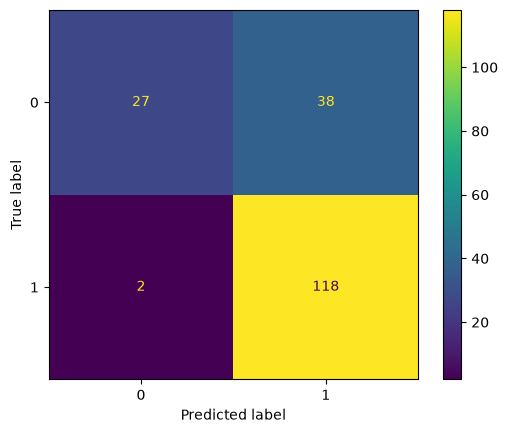

In [99]:
cm_grid_2_dis = ConfusionMatrixDisplay(cm_grid_2)
cm_grid_2_dis.plot()


In [100]:
grid_2_report = classification_report(y_test,grid_2_pred)

#### Final Score results

In [101]:
print('Model_score:',score)
print('Cross_validation_score:',cv_score.mean()*100)
print('Scaled_Model_score:',scaled_model_score)
print('Cross_validation_Scaled_score:',cv_scaled_score.mean()*100)
print("Balanced_Model Score:",balanced_model_score)
print("Balanced_Model_Cv_score:",cv_balanced_model_score)
print("Balanced_Scaled_Model Score:",balanced_scaled_model_score)
print("Balanced_Scaled_Model_Cv_score:",cv_balanced_scaled_model_score)
print("Hyperparameter tuning result:",grid_score*100)
print("Hyperparameter tuning result_2:",grid_2_score*100)


Model_score: 78.37837837837837
Cross_validation_score: 80.61975209916034
Scaled_Model_score: 78.37837837837837
Cross_validation_Scaled_score: 80.61975209916034
Balanced_Model Score: 71.89189189189189
Balanced_Model_Cv_score: 76.05491136878581
Balanced_Scaled_Model Score: 74.5945945945946
Balanced_Scaled_Model_Cv_score: 76.05491136878581
Hyperparameter tuning result: 75.64817361302099
Hyperparameter tuning result_2: 75.64817361302099


In [102]:
grid_classification_report = classification_report(y_test,grid_pred)


#### Final Report Comparison

In [103]:
print('Base Model Report:',Base_model_report)
print('Base Scaled Report:',Base_scaled_model_report)
print('Balanced Model Report:',Balanced_model_report)
print('Balanced Scaled Model Report:',Balanced_scaled_report)
print('Hyper Parameter Tuning Report:',grid_classification_report)
print('Hyper Parameter Tuning Report 2:',grid_2_report)

Base Model Report:               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

Base Scaled Report:               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

Balanced Model Report:               precision    recall  f1-score   support

           0       0.62      0.52      0.57        65
           1       0.76      0.82      0.79       120

    accuracy                           0.72       185
   macro avg       0.69      0.67      0.68       185
weighted avg

| Model             | Accuracy | Weighted F1 | Class 0 Recall | Class 1 Recall |
| ----------------- | -------: | ----------: | -------------: | -------------: |
| Base              |      78% |        0.76 |            42% |            98% |
| Scaled            |      78% |        0.76 |            42% |            98% |
| Balanced          |      72% |        0.71 |        **52%** |            82% |
| Balanced + Scaled |      75% |        0.73 |            45% |            91% |
| Tuned             |      78% |        0.76 |            42% |            98% |


#### Investigating with Next Model (Decision Trees)

In [104]:
def modelselect(mlmodel,x,y):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    mlmodel.fit(x_train,y_train)
    print(f'{mlmodel} Score is:',mlmodel.score(x_test,y_test)*100)
    cvmodel = cross_val_score(mlmodel,x,y,cv=5)
    print(f'Cv {mlmodel} Score is:',cvmodel.mean()*100)

In [105]:
modelselect(model_scaled,x,y)

LogisticRegression() Score is: 78.37837837837837
Cv LogisticRegression() Score is: 80.61975209916034


In [106]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
modelselect(decision_tree,x,y)

DecisionTreeClassifier() Score is: 65.94594594594595
Cv DecisionTreeClassifier() Score is: 72.14980674396907


In [107]:
y_pred_dt = decision_tree.predict(x_test)

In [108]:
cm_dt = confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[33, 32],
       [31, 89]])

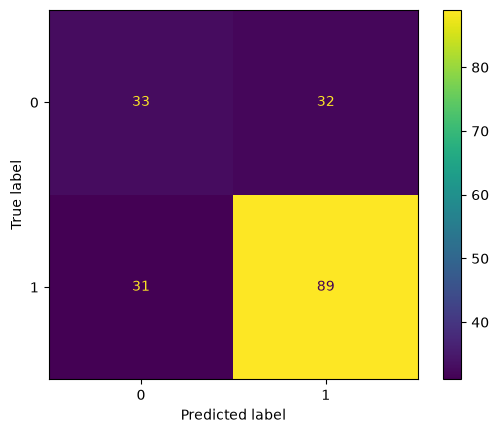

In [109]:
cm_dt_disp = ConfusionMatrixDisplay(cm_dt)
cm_dt_disp.plot()

In [110]:
decision_tree_report = classification_report(y_test,y_pred_dt)
print(decision_tree_report)

              precision    recall  f1-score   support

           0       0.52      0.51      0.51        65
           1       0.74      0.74      0.74       120

    accuracy                           0.66       185
   macro avg       0.63      0.62      0.63       185
weighted avg       0.66      0.66      0.66       185



### Random Forest

In [111]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
modelselect(random_forest,x,y)

RandomForestClassifier() Score is: 78.91891891891892
Cv RandomForestClassifier() Score is: 77.84886045581769


In [112]:
y_pred_rf = random_forest.predict(x_test)

In [124]:
randomforest_report = classification_report(y_test,y_pred_rf)
print(randomforest_report)

              precision    recall  f1-score   support

           0       0.84      0.49      0.62        65
           1       0.78      0.95      0.85       120

    accuracy                           0.79       185
   macro avg       0.81      0.72      0.74       185
weighted avg       0.80      0.79      0.77       185



### XGBoost

In [114]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
modelselect(xgb,x,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) Score is: 74.5945945945946
Cv XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
         

In [125]:
y_pred_xgb = xgb.predict(x_test)
xgb_report = classification_report(y_test,y_pred_xgb)
print(xgb_report)


              precision    recall  f1-score   support

           0       0.70      0.48      0.57        65
           1       0.76      0.89      0.82       120

    accuracy                           0.75       185
   macro avg       0.73      0.68      0.69       185
weighted avg       0.74      0.75      0.73       185



### Gradient Boosting

In [121]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
modelselect(gbc,x,y)

GradientBoostingClassifier() Score is: 75.67567567567568
Cv GradientBoostingClassifier() Score is: 78.01412768226044


In [127]:
y_pred_gbc = gbc.predict(x_test)
gbc_report = classification_report(y_test,y_pred_gbc)
print(gbc_report)

              precision    recall  f1-score   support

           0       0.79      0.42      0.55        65
           1       0.75      0.94      0.83       120

    accuracy                           0.76       185
   macro avg       0.77      0.68      0.69       185
weighted avg       0.76      0.76      0.73       185



In [133]:
print('Model_score:',score)
print('Cross_validation_score:',cv_score.mean()*100)
print('Scaled_Model_score:',scaled_model_score)
print('Cross_validation_Scaled_score:',cv_scaled_score.mean()*100)
print("Balanced_Model Score:",balanced_model_score)
print("Balanced_Model_Cv_score:",cv_balanced_model_score)
print("Balanced_Scaled_Model Score:",balanced_scaled_model_score)
print("Balanced_Scaled_Model_Cv_score:",cv_balanced_scaled_model_score)
print("Hyperparameter tuning result:",grid_score*100)
print("Hyperparameter tuning result_2:",grid_2_score*100)
print("Decision Tree Score:",decision_tree.score(x_test,y_test)*100)
print("Decision Tree Cv Score:",)
print("Random Forest Score:",random_forest.score(x_test,y_test)*100)
print("Random Forest Cv Score:",)
print("XGB Score:",xgb.score(x_test,y_test)*100)
#print("XGB Cv Score:",)
#print("SGD Cv Score:",)
print("GB Score:",gbc.score(x_test,y_test)*100)
#print("GB Cv Score:",)



Model_score: 78.37837837837837
Cross_validation_score: 80.61975209916034
Scaled_Model_score: 78.37837837837837
Cross_validation_Scaled_score: 80.61975209916034
Balanced_Model Score: 71.89189189189189
Balanced_Model_Cv_score: 76.05491136878581
Balanced_Scaled_Model Score: 74.5945945945946
Balanced_Scaled_Model_Cv_score: 76.05491136878581
Hyperparameter tuning result: 75.64817361302099
Hyperparameter tuning result_2: 75.64817361302099
Decision Tree Score: 65.94594594594595
Decision Tree Cv Score:
Random Forest Score: 78.91891891891892
Random Forest Cv Score:
XGB Score: 74.5945945945946
GB Score: 75.67567567567568


In [135]:
print('Base Model Report:',Base_model_report)
print('Base Scaled Report:',Base_scaled_model_report)
print('Balanced Model Report:',Balanced_model_report)
print('Balanced Scaled Model Report:',Balanced_scaled_report)
print('Hyper Parameter Tuning Report:',grid_classification_report)
print('Hyper Parameter Tuning Report 2:',grid_2_report)
print('Decision Tree Report:',decision_tree_report)
print('Random Forest Report:',randomforest_report)
print('XGB Report:',xgb_report)
print('GB Report:',gbc_report)


Base Model Report:               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

Base Scaled Report:               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

Balanced Model Report:               precision    recall  f1-score   support

           0       0.62      0.52      0.57        65
           1       0.76      0.82      0.79       120

    accuracy                           0.72       185
   macro avg       0.69      0.67      0.68       185
weighted avg

| Model                        | Accuracy | Weighted F1 | Class 0 Recall | Class 1 Recall |
| ---------------------------- | -------: | ----------: | -------------: | -------------: |
| Logistic Regression          |      78% |        0.76 |           0.42 |           0.98 |
| Scaled Logistic Regression   |      78% |        0.76 |           0.42 |           0.98 |
| Balanced Logistic Regression |      72% |        0.71 |       **0.52** |           0.82 |
| Balanced + Scaled LR         |      75% |        0.73 |           0.45 |           0.91 |
| Decision Tree                |      66% |        0.66 |           0.51 |           0.74 |
| **Random Forest**            |  **79%** |    **0.77** |       **0.49** |           0.95 |
| XGBoost                      |      75% |        0.73 |           0.48 |           0.89 |
| Gradient Boosting            |      76% |        0.73 |           0.42 |           0.94 |



🟢Best CV accuracy: Logistic Regression
🟢Best test accuracy: Tie — Logistic Regression & Random Forest
🟢Best weighted F1: Random Forest
🟢Best Class 0 recall: Random Forest / Decision Tree / XGBoost at 48%
🟢Most stable CV → test: Random Forest

In [191]:
model_name = ['model','model_scaled','balanced_model','balanced_scaled_model','grid','grid_2','random_forest','decision_tree','xgb','gbc']
model_pred = [y_pred,y_pred_sc,y_pred_bal,y_pred_bal_scaled,grid_pred,grid_2_pred,y_pred_dt,y_pred_rf,y_pred_xgb,y_pred_gbc]

#### ROC AUC Score Analysis

In [192]:
def roc_score_prob(model, x_test, y_test):
    y_prob = model.predict_proba(x_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

In [190]:
print("Logistic:", roc_score_prob(model, x_test, y_test)*100)
print("Random Forest:", roc_score_prob(random_forest, x_test, y_test)*100)
print("Decision Tree:", roc_score_prob(decision_tree, x_test, y_test)*100)
print("XGBoost:", roc_score_prob(xgb, x_test, y_test)*100)
print("Gradient Boosting:", roc_score_prob(gbc, x_test, y_test)*100)

Logistic: 75.56410256410255
Random Forest: 77.31410256410255
Decision Tree: 62.467948717948715
XGBoost: 74.58974358974359
Gradient Boosting: 70.8525641025641


| Model               | Test Accuracy | Weighted F1 |    ROC-AUC |
| ------------------- | ------------: | ----------: | ---------: |
| Logistic Regression |        78.38% |        0.76 |     75.56% |
| **Random Forest**   |      **~79%** |    **0.77** | **77.31%** |
| Decision Tree       |          ~66% |        0.66 |     62.47% |
| XGBoost             |          ~75% |        0.73 |     74.59% |
| Gradient Boosting   |          ~76% |        0.73 |     70.85% |
